In [5]:
from sklearn import tree
import random
import pandas as pd
import numpy as np   
from sklearn import utils
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
from sklearn.preprocessing import MinMaxScaler

class Node:
    def __init__(self, attribute=None, label=None, majority=None,
                 threshold=None, is_cat=False):
        self.attribute = attribute
        self.label = label
        self.majority = majority
        self.threshold = threshold
        self.is_cat = is_cat
        self.children = {}

def stratified_k_fold(df, k=10, y="label"):
    folds = [[] for _ in range(k)]

    classes = df[y].unique()
    class_subsets = {}

    for c in classes:
        subset = df[df[y] == c].sample(frac=1).reset_index(drop=True)
        class_subsets[c] = subset

    for c in classes:
        subset = class_subsets[c]
        for i in range(len(subset)):
            folds[i % k].append(subset.iloc[i])

    folds = [pd.DataFrame(fold).reset_index(drop=True) for fold in folds]

    return folds

def preprocess_dataset(df, target_col):
    df = df.copy()
    Y = df[target_col].values

    if df[target_col].dtype == 'object':
        df[target_col] = pd.factorize(df[target_col])[0]
        Y = df[target_col].values

    cat_cols = [c for c in df.columns if c != target_col and (df[c].dtype == 'object' or "_cat" in c)]
    num_cols = [c for c in df.columns if c != target_col and (df[c].dtype in ['int64', 'float64'])]

    for col in cat_cols:
        df[col] = pd.factorize(df[col])[0]

    if num_cols:
        scaler = MinMaxScaler()
        df[num_cols] = scaler.fit_transform(df[num_cols])
        for col in num_cols:
            #df[col] = df[col].round(2)
            # quantile binning improves performance for credit and parkinsons,
            # hurts digits, and does nothing for rice
            if "pixel" in col:
                df[col] = (df[col] > df[col].mean()).astype(int)
            else:
                df[col] = pd.qcut(df[col], q=5, labels=False, duplicates='drop')

    return utils.shuffle(df)

def entropy(df, y):
    if len(df) == 0: return 0
    probs = df[y].value_counts(normalize=True)
    return -sum(p * math.log2(p) for p in probs if p > 0)

def information_gain(df, attribute, y):
    total_entropy = entropy(df, y)
    values = df[attribute].unique()
    weighted_entropy = 0
    for val in values:
        subset = df[df[attribute] == val]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset, y)
    return total_entropy - weighted_entropy

def majority_class(df, y):
    if df.empty: return None
    return df[y].mode()[0]


def decision_tree(df, attributes, y='label', depth=0, max_depth=None, min_samples_split=2):
    if max_depth is not None and depth >= max_depth:
        return Node(label=majority_class(df, y))
    
    if len(df) < min_samples_split:
        return Node(label=majority_class(df, y))
    
    if len(df[y].unique()) <= 1:
        return Node(label=df[y].iloc[0] if not df.empty else None)
    
    if not attributes:
        return Node(label=majority_class(df, y))
    
    gains = {attr: information_gain(df, attr, y) for attr in attributes}
    best_attribute = max(gains, key=gains.get)

    root = Node(attribute=best_attribute, majority=majority_class(df, y))
    remaining_attrs = [a for a in attributes if a != best_attribute]

    for value in df[best_attribute].unique():
        subset = df[df[best_attribute] == value]
        root.children[value] = decision_tree(subset, remaining_attrs, y, depth=depth + 1, max_depth=max_depth, min_samples_split=min_samples_split)

    return root


# accuracy 
def accuracy(predictions, correct_labels):
    # count the number of correct predictions and divide it by all instances
    correct = 0
    for i in range(len(correct_labels)):
        if predictions[i] == correct_labels[i]:
            correct += 1
    return correct / len(correct_labels)

def predict_instance(node, instance):
    if node.label is not None:
        return node.label
    attribute_value = instance[node.attribute]
    if attribute_value not in node.children:
        return node.majority
    return predict_instance(node.children[attribute_value], instance)


def predict(tree, df):
    return [predict_instance(tree, row) for _, row in df.iterrows()]


def confusion_matrix(preds, labels, positive_class):
    TP = FP = TN = FN = 0

    for i in range(len(labels)):
        if labels[i] == positive_class and preds[i] == positive_class:
            TP += 1
        elif labels[i] != positive_class and preds[i] == positive_class:
            FP += 1
        elif labels[i] != positive_class and preds[i] != positive_class:
            TN += 1
        else:
            FN += 1

    return TP, FP, TN, FN

def accuracy(TP, FP, TN, FN):
    return (TP + TN) / (TP + FP + TN + FN + 1e-12)

def precision(TP, FP):
    return TP / (TP + FP + 1e-12)

def recall(TP, FN):
    return TP / (TP + FN + 1e-12)

def f1(TP, FP, FN):
    p = precision(TP, FP)
    r = recall(TP, FN)
    return 2 * p * r / (p + r + 1e-12)

def accuracy(preds, actual):
    return np.sum(preds == actual) / len(actual)



def run_kfold(df, target_col, k=10, max_depth=None, min_samples_split=2):
    df_clean = preprocess_dataset(df, target_col)
    attributes = [c for c in df_clean.columns if c != target_col]
    folds = stratified_k_fold(df_clean, k=k, y=target_col)
    
    metrics = {
        "train_acc": [], "test_acc": [],
        "train_f1": [], "test_f1": []
    }
    unique_labels = df_clean[target_col].unique()
    for i in range(k):
        test_df = folds[i]
        train_df = pd.concat([folds[j] for j in range(k) if j != i])
              
        tree_model = decision_tree(train_df, attributes, target_col, 
                                   max_depth=max_depth, 
                                   min_samples_split=min_samples_split)

        train_preds = predict(tree_model, train_df)
        test_preds = predict(tree_model, test_df)

        metrics["train_acc"].append(accuracy(np.array(train_preds), train_df[target_col].values))
        metrics["test_acc"].append(accuracy(np.array(test_preds), test_df[target_col].values))

        fold_train_f1s = []
        fold_test_f1s = []
        
        for label in unique_labels:
            tp, fp, tn, fn = confusion_matrix(train_preds, train_df[target_col].values, label)
            fold_train_f1s.append(f1(tp, fp, fn))
            
            tp, fp, tn, fn = confusion_matrix(test_preds, test_df[target_col].values, label)
            fold_test_f1s.append(f1(tp, fp, fn))
            
        metrics["train_f1"].append(np.mean(fold_train_f1s))
        metrics["test_f1"].append(np.mean(fold_test_f1s))
        
    return metrics["train_acc"], metrics["test_acc"], metrics["train_f1"], metrics["test_f1"]


def tune_decision_tree(df, target_col):
    # (5%, 10%, 15%, 20%)
    num_rows = len(df)
    # split_options = [int(num_rows * p) for p in [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]]
    split_options = [int(num_rows * p) for p in [0.01, 0.03, 0.05, 0.10]]
    num_features = len(df.columns) - 1
    # x = int(math.log2(num_features) + 1)
    # depth_options = sorted(list(set([max(2, x - i) for i in [8, 6, 4, 2, 0, -2, -4, -6, -8]])))
    x = 7
    depth_options = sorted(list(set([max(2, x - i) for i in [0, -2, -4, -6,]])))

    print(f"Tuning for dataset with {num_rows} rows and {num_features} features.")
    print(f"Testing Depths: {depth_options}")
    print(f"Testing Splits: {split_options}\n")
    print(f"{'Depth':<8} | {'Split':<8} | {'Test Acc':<10} | {'Test F1':<10}")
    print("-" * 45)

    best_f1 = 0
    best_params = {}

    for d in depth_options:
        for s in split_options:
            _, te_acc, _, te_f1 = run_kfold(
                df, 
                target_col, 
                k=10, 
                max_depth=d, 
                min_samples_split=s
            )
            
            mean_acc = np.mean(te_acc)
            mean_f1 = np.mean(te_f1)
            
            
            print(f"{d:<8} | {s:<8} | {mean_acc:.4f}     | {mean_f1:.4f}")

       
            if mean_f1 > best_f1:
                best_f1 = mean_f1
                best_params = {'depth': d, 'split': s, 'accuracy': mean_acc}

    print("\n" + "="*30)
    print(f"BEST CONFIGURATION:")
    print(f"Max Depth: {best_params['depth']}")
    print(f"Min Split: {best_params['split']}")
    print(f"F1 Score:  {best_f1:.4f}")
    print("="*30)

In [6]:
rice = "../../res/rice.csv"
credit = "../../res/credit_approval.csv"
parkinsons = "../../res/parkinsons.csv"
parkinsons_df = pd.read_csv(parkinsons)
credit_df = pd.read_csv(credit)
rice_df = pd.read_csv(rice)
from sklearn import datasets
digits_dataset_X, digits_dataset_y = datasets.load_digits(return_X_y=True)
digits_df = pd.DataFrame(digits_dataset_X, columns=[f"pixel_{i}" for i in range(64)])
digits_df['label'] = digits_dataset_y

In [7]:
tune_decision_tree(digits_df, "label")

Tuning for dataset with 1797 rows and 64 features.
Testing Depths: [7, 9, 11, 13]
Testing Splits: [17, 53, 89, 179]

Depth    | Split    | Test Acc   | Test F1   
---------------------------------------------
7        | 17       | 0.8136     | 0.8124
7        | 53       | 0.7561     | 0.7568
7        | 89       | 0.7062     | 0.7043
7        | 179      | 0.6328     | 0.6165
9        | 17       | 0.8319     | 0.8311
9        | 53       | 0.7612     | 0.7592
9        | 89       | 0.7067     | 0.7013
9        | 179      | 0.6505     | 0.6360
11       | 17       | 0.8219     | 0.8222
11       | 53       | 0.7626     | 0.7615
11       | 89       | 0.7204     | 0.7171
11       | 179      | 0.6321     | 0.6216
13       | 17       | 0.8141     | 0.8119
13       | 53       | 0.7568     | 0.7568
13       | 89       | 0.7039     | 0.7037
13       | 179      | 0.6383     | 0.6217

BEST CONFIGURATION:
Max Depth: 9
Min Split: 17
F1 Score:  0.8311


In [ ]:
tune_decision_tree(parkinsons_df, "Diagnosis")

Tuning for dataset with 195 rows and 22 features.
Testing Depths: [2, 3, 5, 7, 9, 11, 13]
Testing Splits: [9, 19, 29, 39]

Depth    | Split    | Test Acc   | Test F1   
---------------------------------------------
2        | 9        | 0.8503     | 0.8065
2        | 19       | 0.8117     | 0.7631
2        | 29       | 0.8454     | 0.7922
2        | 39       | 0.8625     | 0.7836
3        | 9        | 0.8681     | 0.8278
3        | 19       | 0.8312     | 0.7890
3        | 29       | 0.8309     | 0.7553
3        | 39       | 0.8620     | 0.7975
5        | 9        | 0.8575     | 0.8157
5        | 19       | 0.8556     | 0.8171
5        | 29       | 0.8362     | 0.7784
5        | 39       | 0.8611     | 0.7906
7        | 9        | 0.8456     | 0.8050
7        | 19       | 0.8211     | 0.7456
7        | 29       | 0.8312     | 0.7815
7        | 39       | 0.8617     | 0.7912
9        | 9        | 0.8323     | 0.7762
9        | 19       | 0.8515     | 0.8086
9        | 29       | 0.8534 

In [ ]:
tune_decision_tree(credit_df, "label")

Tuning for dataset with 653 rows and 15 features.
Testing Depths: [2, 4, 6, 8, 10, 12]
Testing Splits: [32, 65, 97, 130]

Depth    | Split    | Test Acc   | Test F1   
---------------------------------------------
2        | 32       | 0.8622     | 0.8621
2        | 65       | 0.8639     | 0.8636
2        | 97       | 0.8622     | 0.8622
2        | 130      | 0.8622     | 0.8620
4        | 32       | 0.8378     | 0.8358
4        | 65       | 0.8482     | 0.8473
4        | 97       | 0.8588     | 0.8580
4        | 130      | 0.8577     | 0.8566
6        | 32       | 0.8318     | 0.8293
6        | 65       | 0.8302     | 0.8288
6        | 97       | 0.8501     | 0.8491
6        | 130      | 0.8610     | 0.8606
8        | 32       | 0.8378     | 0.8356
8        | 65       | 0.8576     | 0.8568
8        | 97       | 0.8496     | 0.8489
8        | 130      | 0.8620     | 0.8612
10       | 32       | 0.8377     | 0.8356
10       | 65       | 0.8409     | 0.8397
10       | 97       | 0.8437  

In [ ]:
tune_decision_tree(rice_df, "label")

Tuning for dataset with 3810 rows and 7 features.
Testing Depths: [2, 3, 5, 7, 9, 11]
Testing Splits: [190, 381, 571, 762]

Depth    | Split    | Test Acc   | Test F1   
---------------------------------------------
2        | 190      | 0.9215     | 0.9192
2        | 381      | 0.9228     | 0.9205
2        | 571      | 0.9226     | 0.9202
2        | 762      | 0.9239     | 0.9215
3        | 190      | 0.9234     | 0.9210
3        | 381      | 0.9213     | 0.9189
3        | 571      | 0.9202     | 0.9179
3        | 762      | 0.9239     | 0.9215
5        | 190      | 0.9213     | 0.9189
5        | 381      | 0.9234     | 0.9210
5        | 571      | 0.9226     | 0.9202
5        | 762      | 0.9239     | 0.9215
7        | 190      | 0.9223     | 0.9199
7        | 381      | 0.9226     | 0.9203
7        | 571      | 0.9215     | 0.9192
7        | 762      | 0.9239     | 0.9215
9        | 190      | 0.9234     | 0.9210
9        | 381      | 0.9220     | 0.9197
9        | 571      | 0.9239


Final Results:
Training Accuracy: 0.9239
Training F1 Score: 0.9216
Testing Accuracy: 0.9239
Testing F1 Score: 0.9215


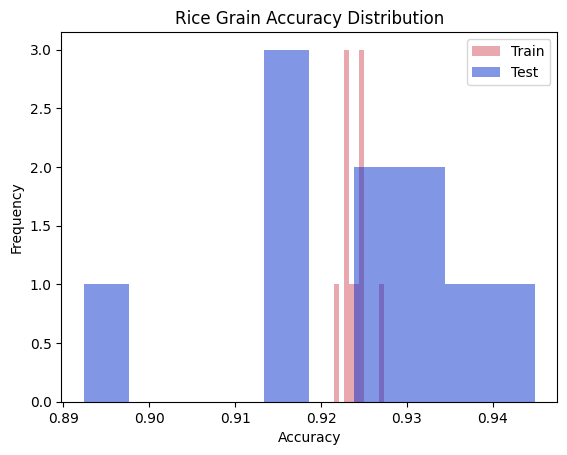

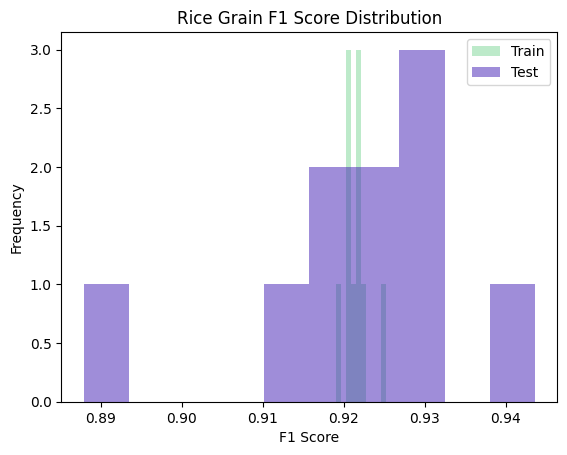

In [ ]:
tr_acc, te_acc, tr_f1, te_f1 = run_kfold(rice_df, "label", k=10, max_depth=11, min_samples_split=762)

print(f"\nFinal Results:")
print(f"Training Accuracy: {np.mean(tr_acc):.4f}")
print(f"Training F1 Score: {np.mean(tr_f1):.4f}")
print(f"Testing Accuracy: {np.mean(te_acc):.4f}")
print(f"Testing F1 Score: {np.mean(te_f1):.4f}")

plt.hist(tr_acc, bins=10, alpha=0.5, label='Train', color='#d4535f')
plt.hist(te_acc, bins=10, alpha=0.5, label='Test', color='#0430cf')
plt.legend()
plt.title("Rice Grain Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

plt.hist(tr_f1, bins=10, alpha=0.5, label='Train', color='#7cd696')
plt.hist(te_f1, bins=10, alpha=0.5, label='Test', color='#401db5')
plt.legend()
plt.title("Rice Grain F1 Score Distribution")
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.show()


Final Results:
Training Accuracy: 0.8746
Training F1 Score: 0.8741
Testing Accuracy: 0.8606
Testing F1 Score: 0.8601


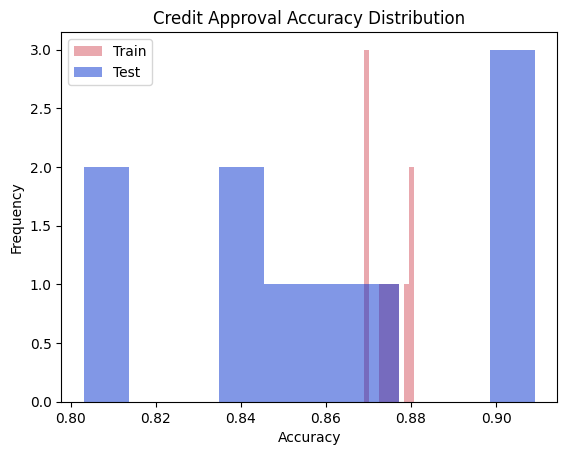

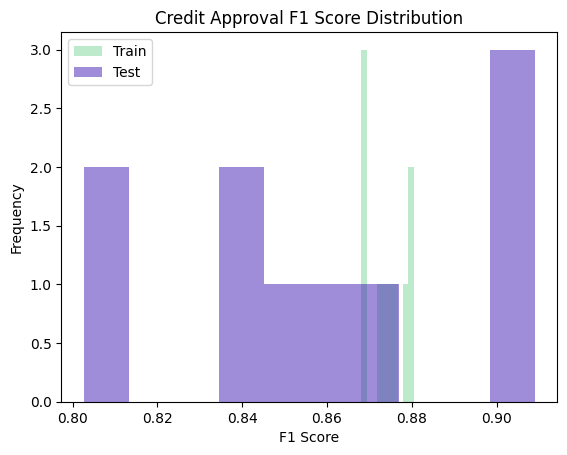

In [39]:
tr_acc, te_acc, tr_f1, te_f1 = run_kfold(credit_df, "label", k=10, max_depth=12, min_samples_split=97)

print(f"\nFinal Results:")
print(f"Training Accuracy: {np.mean(tr_acc):.4f}")
print(f"Training F1 Score: {np.mean(tr_f1):.4f}")
print(f"Testing Accuracy: {np.mean(te_acc):.4f}")
print(f"Testing F1 Score: {np.mean(te_f1):.4f}")

plt.hist(tr_acc, bins=10, alpha=0.5, label='Train', color='#d4535f')
plt.hist(te_acc, bins=10, alpha=0.5, label='Test', color='#0430cf')
plt.legend()
plt.title("Credit Approval Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

plt.hist(tr_f1, bins=10, alpha=0.5, label='Train', color='#7cd696')
plt.hist(te_f1, bins=10, alpha=0.5, label='Test', color='#401db5')
plt.legend()
plt.title("Credit Approval F1 Score Distribution")
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.show()



Final Results:
Training Accuracy: 0.9345
Training F1 Score: 0.9165
Testing Accuracy: 0.8508
Testing F1 Score: 0.8101


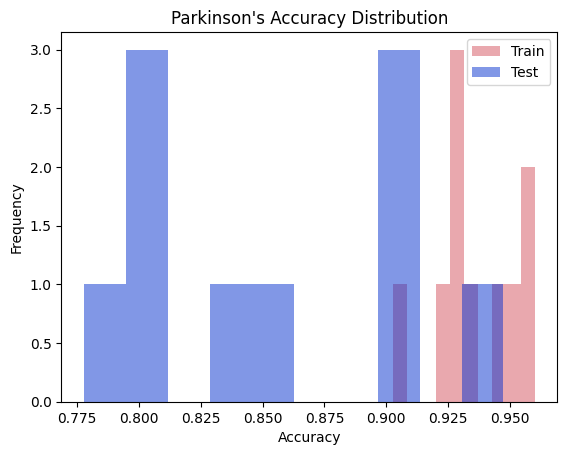

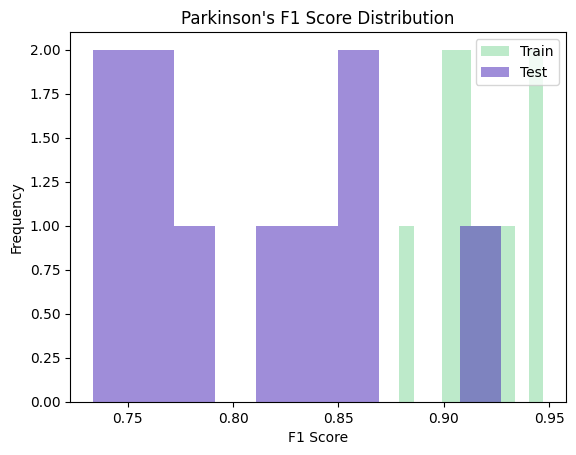

In [53]:
tr_acc, te_acc, tr_f1, te_f1 = run_kfold(parkinsons_df, "Diagnosis", k=10, max_depth=7, min_samples_split=9)

print(f"\nFinal Results:")
print(f"Training Accuracy: {np.mean(tr_acc):.4f}")
print(f"Training F1 Score: {np.mean(tr_f1):.4f}")
print(f"Testing Accuracy: {np.mean(te_acc):.4f}")
print(f"Testing F1 Score: {np.mean(te_f1):.4f}")

plt.hist(tr_acc, bins=10, alpha=0.5, label='Train', color='#d4535f')
plt.hist(te_acc, bins=10, alpha=0.5, label='Test', color='#0430cf')
plt.legend()
plt.title("Parkinson's Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

plt.hist(tr_f1, bins=10, alpha=0.5, label='Train', color='#7cd696')
plt.hist(te_f1, bins=10, alpha=0.5, label='Test', color='#401db5')
plt.legend()
plt.title("Parkinson's F1 Score Distribution")
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.show()



Final Results:
Training Accuracy: 0.8936
Training F1 Score: 0.8935
Testing Accuracy: 0.8344
Testing F1 Score: 0.8327


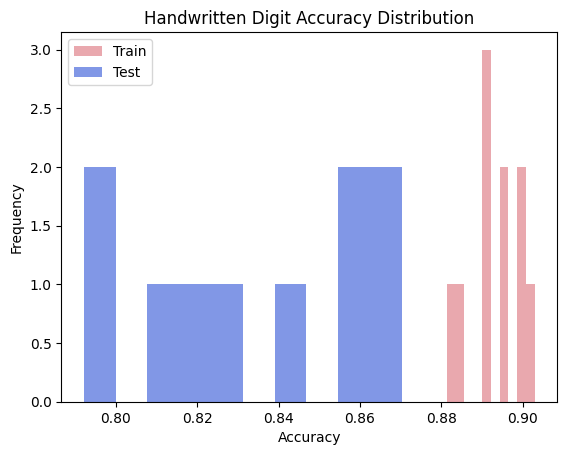

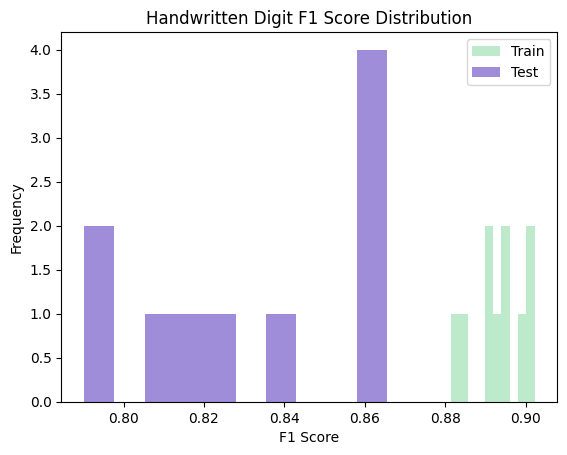

In [55]:
tr_acc, te_acc, tr_f1, te_f1 = run_kfold(digits_df, "label", k=10, max_depth=9, min_samples_split=17)

print(f"\nFinal Results:")
print(f"Training Accuracy: {np.mean(tr_acc):.4f}")
print(f"Training F1 Score: {np.mean(tr_f1):.4f}")
print(f"Testing Accuracy: {np.mean(te_acc):.4f}")
print(f"Testing F1 Score: {np.mean(te_f1):.4f}")

plt.hist(tr_acc, bins=10, alpha=0.5, label='Train', color='#d4535f')
plt.hist(te_acc, bins=10, alpha=0.5, label='Test', color='#0430cf')
plt.legend()
plt.title("Handwritten Digit Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

plt.hist(tr_f1, bins=10, alpha=0.5, label='Train', color='#7cd696')
plt.hist(te_f1, bins=10, alpha=0.5, label='Test', color='#401db5')
plt.legend()
plt.title("Handwritten Digit F1 Score Distribution")
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.show()
